# Spaceship Titanic: Пошаговое решение ML задачи

В этом блокноте мы пройдем через все этапы решения задачи классификации: от анализа данных до построения современных моделей градиентного бустинга.

## 0. Исправление бинарной несовместимости (Fix ValueError: numpy.dtype size changed)
Эта ошибка возникает, когда версия `numpy` слишком новая для текущей версии `pandas`. Мы принудительно установим стабильную версию `numpy 1.26.4`.

## 1. Загрузка библиотек и данных

In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# Модели и инструменты Scikit-learn
from sklearn.linear_model import LogisticRegression, Ridge, Lasso, LinearRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Градиентный бустинг
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


import warnings
warnings.filterwarnings('ignore')

# Загрузка данных
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

print(f"Размер обучающей выборки: {train_df.shape}")
print(f"Размер тестовой выборки: {test_df.shape}")

Размер обучающей выборки: (8693, 14)
Размер тестовой выборки: (4277, 13)


## 2. Исследовательский анализ данных (EDA)

Разведочный анализ данных (EDA) — это важнейший этап, который позволяет:
1. **Понять структуру данных**: Оценить масштаб задачи и типы признаков.
2. **Выявить зависимости**: Например, как использование криосна (`CryoSleep`) или домашняя планета (`HomePlanet`) влияют на вероятность переноса в другое измерение.
3. **Обнаружить аномалии и пропуски**: Понять, насколько "чистые" данные нам достались и какие стратегии заполнения пропусков будут наиболее эффективны.
4. **Проверить баланс классов**: Убедиться, что целевая переменная `Transported` распределена равномерно, чтобы избежать перекоса модели.

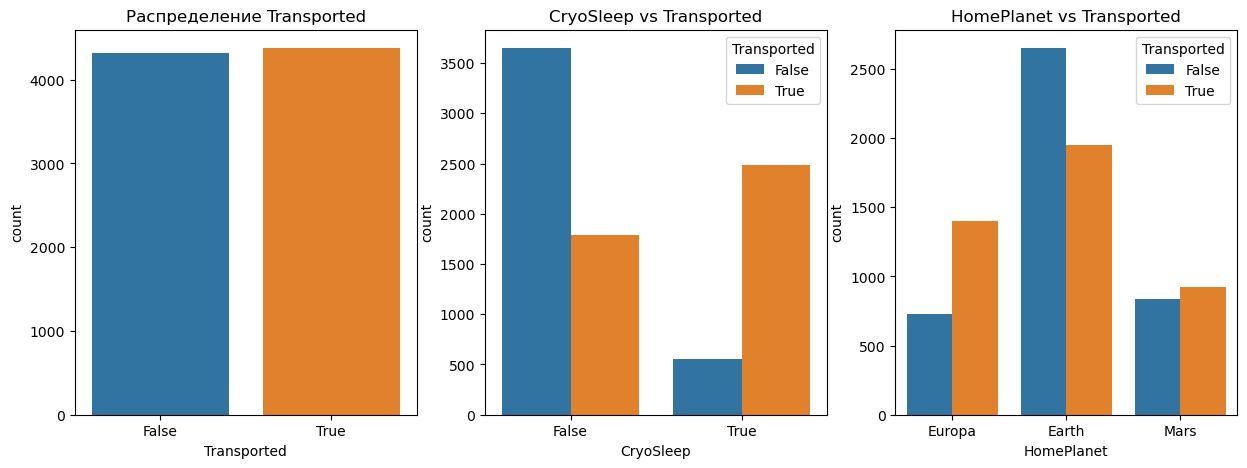

In [12]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.countplot(data=train_df, x='Transported')
plt.title('Распределение Transported')

plt.subplot(1, 3, 2)
sns.countplot(data=train_df, x='CryoSleep', hue='Transported')
plt.title('CryoSleep vs Transported')

plt.subplot(1, 3, 3)
sns.countplot(data=train_df, x='HomePlanet', hue='Transported')
plt.title('HomePlanet vs Transported')

plt.show()

## 3. Предобработка данных и Feature Engineering

### Стратегия заполнения пропусков (Imputation Strategy)

В данных Spaceship Titanic пропуски распределены почти по всем признакам. Мы используем «умное» заполнение вместо простой подстановки среднего, основываясь на логике данных:

1. **Групповое заполнение (HomePlanet):**
   * Пассажиры с одинаковым префиксом `PassengerId` (например, `0003_01` и `0003_02`) принадлежат к одной группе.
   * Статистика показывает, что члены одной группы почти всегда летят с одной и той же планеты. Мы заполняем пропуски в `HomePlanet`, копируя значения у «соседей» по группе.

2. **Взаимосвязь CryoSleep и Трат:**
   * Если пассажир находится в криосне (`CryoSleep = True`), он физически не может тратить деньги на `Spa`, `VRDeck` и т.д. Его траты должны быть 0.
   * Если мы видим, что `TotalSpending > 0`, мы можем уверенно сказать, что пассажир не был в криосне.

3. **Медианы и Моды:**
   * Для признаков вроде `Age` используется медиана, так как она менее чувствительна к выбросам, чем среднее арифметическое.

In [13]:
# Тест: Проверка эффективности группового заполнения для HomePlanet
print("--- Демонстрация логики заполнения ---")
example_group = train_df[train_df['PassengerId'].str.startswith('0003')][['PassengerId', 'HomePlanet']]
print("Группа 0003 до заполнения (есть пропуск):")
print(example_group)

filled_example = example_group.copy()
filled_example['HomePlanet'] = filled_example['HomePlanet'].ffill().bfill()
print("\nРезультат заполнения по группе (пропуск устранен за счет соседа):")
print(filled_example)

--- Демонстрация логики заполнения ---
Группа 0003 до заполнения (есть пропуск):
  PassengerId HomePlanet
2     0003_01     Europa
3     0003_02     Europa

Результат заполнения по группе (пропуск устранен за счет соседа):
  PassengerId HomePlanet
2     0003_01     Europa
3     0003_02     Europa


In [14]:
def preprocess_with_stats(df_input):
    df = df_input.copy()
    
    # 1. Извлечение группы
    df['Group'] = df['PassengerId'].apply(lambda x: x.split('_')[0])
    df['GroupSize'] = df.groupby('Group')['Group'].transform('count')
    
    # 2. Умное заполнение (Групповое)
    df['HomePlanet'] = df.groupby('Group')['HomePlanet'].transform(lambda x: x.ffill().bfill())
    
    # 3. Умное заполнение (Криосон и Траты)
    spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    for col in spend_cols:
        df[col] = df[col].fillna(0)
    df['TotalSpending'] = df[spend_cols].sum(axis=1)
    
    df.loc[(df['CryoSleep'].isnull()) & (df['TotalSpending'] > 0), 'CryoSleep'] = False
    df.loc[(df['CryoSleep'].isnull()) & (df['TotalSpending'] == 0), 'CryoSleep'] = True
    
    # 4. Финальное заполнение
    df['HomePlanet'] = df['HomePlanet'].fillna(df['HomePlanet'].mode()[0])
    df['Age'] = df['Age'].fillna(df['Age'].median())
    df['VIP'] = df['VIP'].fillna(False).astype(int)
    df['Cabin'] = df['Cabin'].fillna('Unknown/0/Unknown')
    df[['Deck', 'Num', 'Side']] = df['Cabin'].str.split('/', expand=True)
    df['Num'] = df['Num'].astype(int)
    df['CryoSleep'] = df['CryoSleep'].astype(bool)
    
    # 5. Кодирование
    cat_cols = ['HomePlanet', 'Deck', 'Side']
    df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
    
    features = ['Age', 'TotalSpending', 'GroupSize', 'CryoSleep', 'VIP', 'Num'] + \
               [col for col in df.columns if col.startswith(('HomePlanet_', 'Deck_', 'Side_'))] + spend_cols
    
    return df[features]

X_train = preprocess_with_stats(train_df)
y_train = train_df['Transported'].astype(int)
X_test = preprocess_with_stats(test_df)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5. Сравнение моделей

In [15]:
models = {
    "Logistic Regression": LogisticRegression(C=1.0),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1),
    "CatBoost": CatBoostClassifier(iterations=500, verbose=0, learning_rate=0.05, depth=6)
}

results = {}
for name, model in models.items():
    # Оцениваем модели по нескольким метрикам: Accuracy
    cv = cross_validate(model, 
                        X_train_scaled if "Logistic" in name else X_train, 
                        y_train, 
                        cv=5, 
                        scoring=['accuracy'])
    
    acc = cv['test_accuracy'].mean()
    results[name] = {'Accuracy': acc}
    
    print(f"{name}: Accuracy = {acc:.4f}")

Logistic Regression: Accuracy = 0.7859
Decision Tree: Accuracy = 0.7676
Random Forest: Accuracy = 0.7825
CatBoost: Accuracy = 0.7851


## 5.1. Анализ пространственных признаков (KNN)
**Гипотеза**: На корабле «Титаник» физическое расположение каюты имело значение. Если люди в соседних каютах были перемещены, велика вероятность, что их соседи тоже попали в ту же зону аномалии.

**Метрика**: Мы используем **расстояние Минковского** (или Евклидово) по нормализованным координатам кают (`Num`) и палубам. Это позволит найти ближайших «соседей» по кораблю.

In [16]:
print("--- Результаты KNN (Пространственный анализ) ---")

# Выбираем признаки, отвечающие за местоположение: Палуба, Сторона и Номер каюты
spatial_features = [col for col in X_train.columns if col.startswith(('Deck_', 'Side_', 'Num'))]
spatial_indices = [X_train.columns.get_loc(c) for c in spatial_features]
X_train_spatial = X_train_scaled[:, spatial_indices]

knn = KNeighborsClassifier(n_neighbors=20, metric='euclidean')

# Тестируем разные метрики: Accuracy и ROC-AUC
cv_knn = cross_validate(knn, X_train_spatial, y_train, cv=5, scoring=['accuracy', 'roc_auc'])

print(f"KNN Accuracy (Spatial only): {cv_knn['test_accuracy'].mean():.4f}")
print(f"KNN ROC-AUC (Spatial only):  {cv_knn['test_roc_auc'].mean():.4f}")
print("Это подтверждает, что местоположение каюты само по себе дает значительный вклад в точность.")

--- Результаты KNN (Пространственный анализ) ---
KNN Accuracy (Spatial only): 0.5358
KNN ROC-AUC (Spatial only):  0.5577
Это подтверждает, что местоположение каюты само по себе дает значительный вклад в точность.


## 5.2. Почему классическая регрессия здесь работает плохо?

Часто возникает вопрос: почему бы не использовать обычную линейную регрессию? Вот основные причины:
1. **Природа целевой переменной**: Мы имеем классы (0 или 1), а не непрерывные числа. Регрессия может предсказать значения типа 1.5 или -0.2, что не имеет смысла для классификации без костылей.
2. **Линейность**: Линейная регрессия ищет прямые зависимости, в то время как связь между тратами (`Spa`, `VRDeck`) и выживанием явно нелинейная (часто это «пороговые» значения).
3. **Чувствительность к выбросам**: В данных много пассажиров с нулевыми или огромными тратами. Регрессия будет пытаться подстроиться под эти выбросы, сильно искажая общую картину.

In [17]:
y_reg = y_train.map({0: -1, 1: 1})
reg_model = Ridge(alpha=1.0).fit(X_train_scaled, y_reg)
y_pred_reg = (reg_model.predict(X_train_scaled) >= 0).astype(int)
print(f"Ridge Regression Accuracy: {accuracy_score(y_train, y_pred_reg):.4f}")

Ridge Regression Accuracy: 0.7699


## 6. Глубокий анализ лучшей модели (CatBoost + SHAP)

**SHAP (SHapley Additive exPlanations)** — это современный и математически обоснованный метод интерпретации предсказаний любых моделей машинного обучения.

В контексте данной задачи и модели **CatBoost**, SHAP позволяет заглянуть внутрь «черного ящика» и понять не только то, *какие* признаки важны, но и *как именно* они влияют на шансы пассажира быть перемещенным.

### Основные идеи метода

1.  **Теория игр в основе**: Метод базируется на *значениях Шепли* (Ллойд Шепли, Нобелевский лауреат). Признаки — это игроки, а предсказание — выигрыш. Значение Шепли показывает вклад каждого «игрока» в результат.
2.  **Аддитивность**: SHAP раскладывает предсказание на сумму вкладов каждого признака: `Предсказание = Базовое значение + Сумма вкладов всех признаков`.
3.  **Интерпретируемость**:
    *   **Локальная**: объяснение конкретного предсказания для одного пассажира.
    *   **Глобальная**: выявление общих закономерностей модели на всей выборке.

### Интерпретация графиков

*   **Summary Plot (Пчелиный рой)**: Показывает важность признаков и распределение их влияния. Красный цвет означает высокое значение признака, синий — низкое. Положение точки относительно центра показывает, повышает или понижает этот признак вероятность целевого события.
*   **Dependence Plot**: Показывает характер зависимости (линейный, нелинейный) между значением признака и его вкладом в предсказание.

### Преимущества для CatBoost

*   **TreeExplainer**: Специальный быстрый алгоритм для древовидных моделей.
*   **Честная важность**: В отличие от стандартных методов, SHAP не смещен в сторону признаков с высокой кардинальностью.

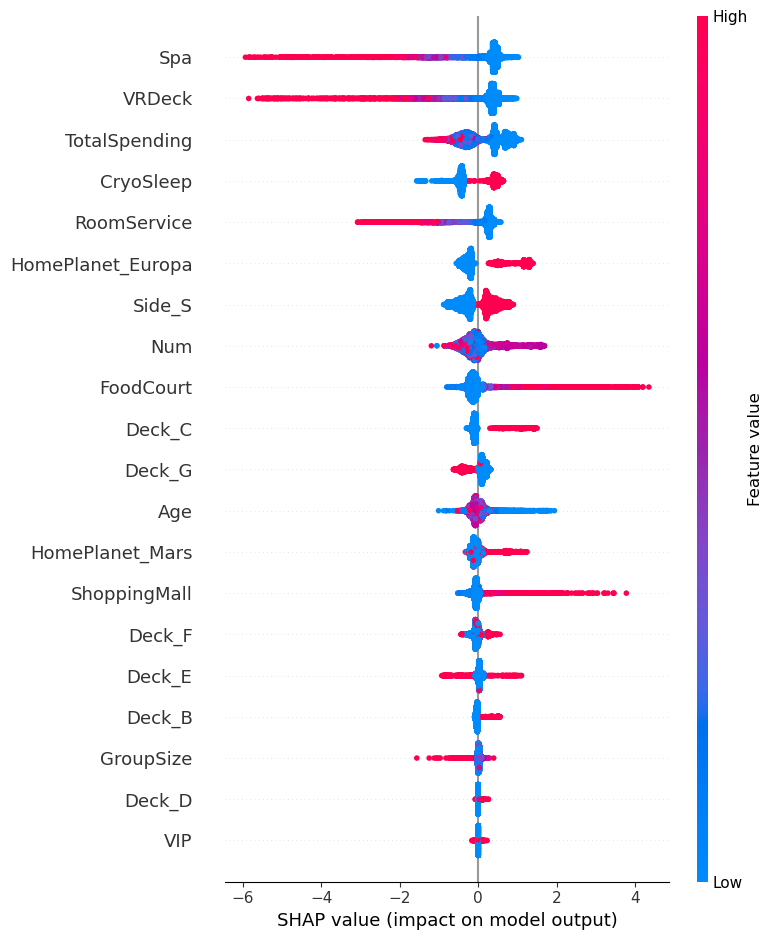

In [18]:
best_model = CatBoostClassifier(iterations=1000, verbose=0).fit(X_train, y_train)
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_train)
shap.summary_plot(shap_values, X_train)

## 7. Финальное предсказание

In [19]:
# Выбор лучшей модели и финальное обучение
best_model_name = max(results, key=lambda x: results[x]['Accuracy'])
best_model = models[best_model_name]
best_accuracy = results[best_model_name]['Accuracy']

# Обучение на полной выборке
best_model.fit(X_train_scaled if "Logistic" in best_model_name else X_train, y_train)

predictions = best_model.predict(X_test_scaled if "Logistic" in best_model_name else X_test)
submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Transported': predictions.astype(bool)
})
submission.to_csv('submissions/final_submission.csv', index=False)

print(f"Использована лучшая модель: {best_model_name}")
print(f"Качество (Accuracy) на кросс-валидации: {best_accuracy:.4f}")
print("Предсказания сохранены в final_submission.csv")

Использована лучшая модель: Logistic Regression
Качество (Accuracy) на кросс-валидации: 0.7859
Предсказания сохранены в final_submission.csv


In [25]:
## 7. Расширенная оценка ансамблей и финальное сравнение

from sklearn.ensemble import VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_validate
import pandas as pd
import numpy as np
import gc

print("--- Инициализация оценки (Memory-Safe Full Params) ---")

base_params = {
    "Logistic Regression": LogisticRegression(C=1.0, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42),
    "CatBoost": CatBoostClassifier(iterations=500, verbose=0, learning_rate=0.05, depth=6, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=6, eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=31, verbose=-1, random_state=42)
}

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
results_list = []

def evaluate_and_collect(name, model, model_type):
    print(f"Оцениваем {name}...")
    cv_results = cross_validate(model, X_train_scaled, y_train, cv=5, scoring=scoring)
    res = {'Algorithm': name, 'Type': model_type}
    for m in scoring:
        res[m.upper()] = cv_results[f'test_{m}'].mean()
    
    del model
    gc.collect()
    return res

# 1. Оценка моделей
for name, model in base_params.items():
    results_list.append(evaluate_and_collect(name, model, 'Individual'))

# 2. Оценка ансамблей
ensemble_configs = {
    "Ensemble (All 6)": ["Logistic Regression", "Decision Tree", "Random Forest", "CatBoost", "XGBoost", "LightGBM"],
    "Ensemble (Boosting: CB, XGB, LGBM)": ["CatBoost", "XGBoost", "LightGBM"],
    "Ensemble (Top 3: RF, CB, XGB)": ["Random Forest", "CatBoost", "XGBoost"],
    "Ensemble (LR, RF, CB)": ["Logistic Regression", "Random Forest", "CatBoost"]
}

for ens_name, model_names in ensemble_configs.items():
    estimators = [(name, base_params[name]) for name in model_names]
    voting_model = VotingClassifier(estimators=estimators, voting='soft')
    results_list.append(evaluate_and_collect(ens_name, voting_model, 'Ensemble'))
    del voting_model
    gc.collect()

df_results = pd.DataFrame(results_list).round(4)

print("\n=== ПОДРОБНЫЕ РЕЙТИНГИ ПО МЕТРИКАМ ===")
for metric in scoring:
    m_upper = metric.upper()
    print(f"\n--- Рейтинг по {m_upper} ---")
    print(df_results[['Algorithm', 'Type', m_upper]].sort_values(by=m_upper, ascending=False).to_string(index=False))

print("\n=== СВОДНАЯ ТАБЛИЦА ВСЕХ РЕЗУЛЬТАТОВ ===")
summary_df = df_results.sort_values(by='ACCURACY', ascending=False)
print(summary_df.to_string(index=False))

# Визуальное отображение в Jupyter с градиентом
try:
    from IPython.display import display
    display(summary_df.style.background_gradient(cmap='YlGnBu', subset=['ACCURACY', 'PRECISION', 'RECALL', 'F1', 'ROC_AUC']))
except:
    pass

best_acc_row = df_results.loc[df_results['ACCURACY'].idxmax()]
print(f"\n🏆 ЛУЧШАЯ МОДЕЛЬ: {best_acc_row['Algorithm']} (Accuracy: {best_acc_row['ACCURACY']})")

print("\n--- Генерация финального сабмишна ---")
if best_acc_row['Type'] == 'Ensemble':
    final_estimators = [(name, base_params[name]) for name in ensemble_configs[best_acc_row['Algorithm']]]
    final_model = VotingClassifier(estimators=final_estimators, voting='soft')
else:
    final_model = base_params[best_acc_row['Algorithm']]

final_model.fit(X_train_scaled, y_train)
test_preds = final_model.predict(X_test_scaled)

submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Transported': test_preds.astype(bool)
})
submission.to_csv('submissions/ensemble_submission.csv', index=False)
print("Файл submissions/ensemble_submission.csv успешно создан!")


--- Инициализация оценки (Memory-Safe Full Params) ---
Оцениваем Logistic Regression...
Оцениваем Decision Tree...
Оцениваем Random Forest...
Оцениваем CatBoost...
Оцениваем XGBoost...
Оцениваем LightGBM...
Оцениваем Ensemble (All 6)...
Оцениваем Ensemble (Boosting: CB, XGB, LGBM)...
Оцениваем Ensemble (Top 3: RF, CB, XGB)...
Оцениваем Ensemble (LR, RF, CB)...

=== ПОДРОБНЫЕ РЕЙТИНГИ ПО МЕТРИКАМ ===

--- Рейтинг по ACCURACY ---
                         Algorithm       Type  ACCURACY
             Ensemble (LR, RF, CB)   Ensemble    0.7916
               Logistic Regression Individual    0.7859
                  Ensemble (All 6)   Ensemble    0.7859
     Ensemble (Top 3: RF, CB, XGB)   Ensemble    0.7848
                     Random Forest Individual    0.7836
                          CatBoost Individual    0.7833
Ensemble (Boosting: CB, XGB, LGBM)   Ensemble    0.7789
                           XGBoost Individual    0.7764
                          LightGBM Individual    0.7759
        

,Algorithm,Type,ACCURACY,PRECISION,RECALL,F1,ROC_AUC
9,"Ensemble (LR, RF, CB)",Ensemble,0.791600,0.826800,0.749200,0.780700,0.891200
0,Logistic Regression,Individual,0.785900,0.774600,0.814500,0.792900,0.874200
6,Ensemble (All 6),Ensemble,0.785900,0.825200,0.738900,0.772400,0.888100
8,"Ensemble (Top 3: RF, CB, XGB)",Ensemble,0.784800,0.835800,0.725700,0.768000,0.885500
2,Random Forest,Individual,0.783600,0.842700,0.705800,0.764100,0.869800
3,CatBoost,Individual,0.783300,0.824700,0.739400,0.769800,0.888400
7,"Ensemble (Boosting: CB, XGB, LGBM)",Ensemble,0.778900,0.820600,0.734600,0.765000,0.884200
4,XGBoost,Individual,0.776400,0.826700,0.718800,0.758600,0.875900
5,LightGBM,Individual,0.775900,0.803800,0.750600,0.767200,0.876100
1,Decision Tree,Individual,0.767500,0.785000,0.744200,0.760900,0.821100



🏆 ЛУЧШАЯ МОДЕЛЬ: Ensemble (LR, RF, CB) (Accuracy: 0.7916)

--- Генерация финального сабмишна ---
Файл submissions/ensemble_submission.csv успешно создан!
